# Metrica Tracking Data Quality Exploration

This notebook performs a comprehensive quality analysis of the Metrica tracking dataset for **Sample Game 1**. We look at dataset statistics, player visibility, coordinate sanity, and motion statistics to identify potential noise, missing data, and tracking issues.

### Rationale & Design:
- **Read-Only**: We analyze the data as-is without modification.
- **Reproducible**: We leverage the project's standard parser (`src/data/metrica_parser.py`).
- **Detailed Gaps**: We analyze visibility per player and missing gap length distributions.
- **Anomalies**: We check for coordinates outside the canonical `[0.0, 1.0]` range and calculate player speeds to identify unphysical tracking jumps.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in the path
sys.path.insert(0, os.path.abspath('../../'))

from src.data.metrica_parser import load_metrica_match

# Define file paths
home_path = '../../data/raw/metrica/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Home_Team.csv'
away_path = '../../data/raw/metrica/data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv'
match_id = 'sample_game_1'

# Load the tracking data using the project's standard parser
players_df, ball_df = load_metrica_match(home_path, away_path, match_id)

print(f"Loaded {len(players_df)} player tracking records.")


Loaded 4060168 player tracking records.


## 1. Dataset Overview

We compute fundamental dataset properties including total frames, duration, sampling frequency (FPS), and player counts.


In [2]:
# 1. Dataset Overview
total_frames = players_df['frame'].nunique()
duration = players_df['timestamp'].max() - players_df['timestamp'].min()

# Calculate FPS
first_row = players_df.iloc[0]
df_sp = players_df[(players_df['player_id'] == first_row['player_id']) & (players_df['team'] == first_row['team'])].sort_values('frame')
fps = 1.0 / df_sp['timestamp'].diff().mean()

unique_players = players_df['player_id'].nunique()
home_players = players_df[players_df['team'] == 'home']['player_id'].nunique()
away_players = players_df[players_df['team'] == 'away']['player_id'].nunique()

overview_df = pd.DataFrame({
    'Metric': ['Total Frames', 'Duration (s)', 'FPS', 'Unique Players (Total)', 'Home Players', 'Away Players'],
    'Value': [total_frames, f"{duration:.2f}", f"{fps:.1f}", unique_players, home_players, away_players]
})

print("### Dataset Overview Table")
print(overview_df.to_string(index=False))


### Dataset Overview Table
                Metric   Value
          Total Frames  145006
          Duration (s) 5800.20
                   FPS    25.0
Unique Players (Total)      28
          Home Players      14
          Away Players      14


## 2. Frame-Level Visibility

We analyze player counts present on the pitch for each frame to determine overall tracking completeness.


Percentage of frames with >=22 visible players: 100.00%
Percentage of frames with <22 visible players: 0.00%


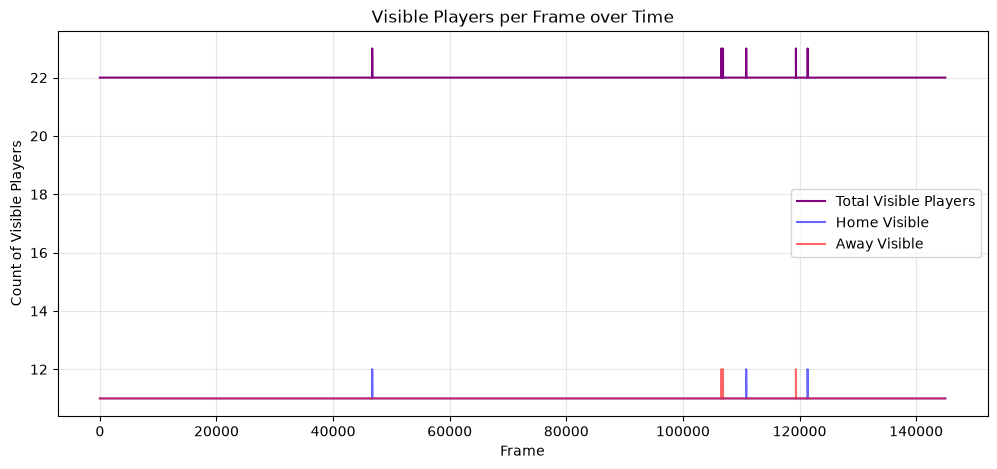

In [3]:
# 2. Frame-level Visibility
vis_per_frame = players_df.groupby(['frame', 'team'])['visible'].sum().unstack()
vis_per_frame['total'] = vis_per_frame['home'] + vis_per_frame['away']

# Compute percentages
p_22_or_more = (vis_per_frame['total'] >= 22).mean() * 100
p_less_than_22 = (vis_per_frame['total'] < 22).mean() * 100

print(f"Percentage of frames with >=22 visible players: {p_22_or_more:.2f}%")
print(f"Percentage of frames with <22 visible players: {p_less_than_22:.2f}%")

# Save a figure of visible player count over time
plt.figure(figsize=(12, 5))
plt.plot(vis_per_frame.index, vis_per_frame['total'], label='Total Visible Players', color='purple')
plt.plot(vis_per_frame.index, vis_per_frame['home'], label='Home Visible', color='blue', alpha=0.6)
plt.plot(vis_per_frame.index, vis_per_frame['away'], label='Away Visible', color='red', alpha=0.6)
plt.title('Visible Players per Frame over Time')
plt.xlabel('Frame')
plt.ylabel('Count of Visible Players')
plt.legend()
plt.grid(True, alpha=0.3)

# Ensure results/figures/ directory exists
os.makedirs('../../results/figures', exist_ok=True)
plt.savefig('../../results/figures/visible_players_timeline.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 & 4. Player-Level Coverage and Gap Analysis

For each player, we calculate the tracking coverage percentage, total missing frames, continuous tracked/missing run lengths, and descriptive gap statistics.


In [4]:
# 3 & 4. Player-level Coverage and Gap Analysis
player_stats = []
all_gap_lengths = []

for (team, pid), group in players_df.groupby(['team', 'player_id']):
    sorted_group = group.sort_values('frame')
    visible_series = sorted_group['visible']
    total_p_frames = len(visible_series)
    missing_p_frames = (~visible_series).sum()
    vis_pct = (visible_series.sum() / total_p_frames) * 100
    
    # Calculate run lengths of visibility and missingness
    run_id = (visible_series != visible_series.shift()).cumsum()
    run_sizes = visible_series.groupby(run_id).agg(['first', 'size'])
    
    visible_runs = run_sizes[run_sizes['first'] == True]['size']
    missing_runs = run_sizes[run_sizes['first'] == False]['size']
    
    # Track all gaps for aggregate analysis
    all_gap_lengths.extend(missing_runs.tolist())
    
    # Convert run lengths to seconds
    min_vis_sec = (visible_runs.min() / fps) if not visible_runs.empty else 0.0
    max_vis_sec = (visible_runs.max() / fps) if not visible_runs.empty else 0.0
    min_miss_sec = (missing_runs.min() / fps) if not missing_runs.empty else 0.0
    max_miss_sec = (missing_runs.max() / fps) if not missing_runs.empty else 0.0
    
    # Gap statistics in frames
    num_gaps = len(missing_runs)
    mean_gap = missing_runs.mean() if num_gaps > 0 else 0.0
    med_gap = missing_runs.median() if num_gaps > 0 else 0.0
    p95_gap = missing_runs.quantile(0.95) if num_gaps > 0 else 0.0
    max_gap = missing_runs.max() if num_gaps > 0 else 0.0
    
    player_stats.append({
        'Team': team,
        'Player ID': pid,
        'Visibility %': f"{vis_pct:.2f}%",
        'Missing Frames': missing_p_frames,
        'Min Visible Duration (s)': f"{min_vis_sec:.2f}",
        'Max Visible Duration (s)': f"{max_vis_sec:.2f}",
        'Min Missing Duration (s)': f"{min_miss_sec:.2f}",
        'Max Missing Duration (s)': f"{max_miss_sec:.2f}",
        'Gap Count': num_gaps,
        'Mean Gap (frames)': f"{mean_gap:.1f}",
        'Median Gap (frames)': f"{med_gap:.1f}",
        '95th Pct Gap (frames)': f"{p95_gap:.1f}",
        'Max Gap (frames)': max_gap
    })

player_stats_df = pd.DataFrame(player_stats)
print("### Player-level Coverage and Gap Analysis Table")
print(player_stats_df.to_string(index=False))


### Player-level Coverage and Gap Analysis Table
Team Player ID Visibility %  Missing Frames Min Visible Duration (s) Max Visible Duration (s) Min Missing Duration (s) Max Missing Duration (s)  Gap Count Mean Gap (frames) Median Gap (frames) 95th Pct Gap (frames)  Max Gap (frames)
away        15      100.00%               0                  5800.24                  5800.24                     0.00                     0.00          0               0.0                 0.0                   0.0               0.0
away        16      100.00%               0                  5800.24                  5800.24                     0.00                     0.00          0               0.0                 0.0                   0.0               0.0
away        17      100.00%               0                  5800.24                  5800.24                     0.00                     0.00          0               0.0                 0.0                   0.0               0.0
away        18     

## 5. Aggregate Gap Distribution

We look at the overall distribution of missing data gaps across all players.


### Aggregate Gap Length Quantiles
 Quantile  Gap Length (frames)  Gap Length (seconds)
     0.10             26478.20             1059.1280
     0.25             37142.00             1485.6800
     0.50             72502.50             2900.1000
     0.75            107863.00             4314.5200
     0.90            118526.80             4741.0720
     0.95            120284.95             4811.3980
     0.99            121169.79             4846.7916


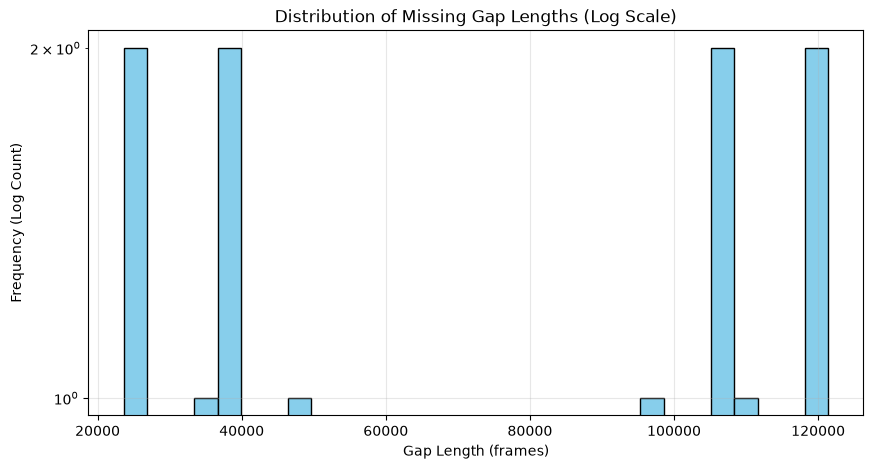

In [5]:
# 5. Aggregate Gap Distribution
all_gaps_series = pd.Series(all_gap_lengths)

if not all_gaps_series.empty:
    quantiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    quantile_vals = all_gaps_series.quantile(quantiles)
    gap_quantiles_df = pd.DataFrame({
        'Quantile': quantiles,
        'Gap Length (frames)': quantile_vals.values,
        'Gap Length (seconds)': (quantile_vals.values / fps)
    })
    print("### Aggregate Gap Length Quantiles")
    print(gap_quantiles_df.to_string(index=False))
    
    plt.figure(figsize=(10, 5))
    plt.hist(all_gaps_series, bins=30, color='skyblue', edgecolor='black', log=True)
    plt.title('Distribution of Missing Gap Lengths (Log Scale)')
    plt.xlabel('Gap Length (frames)')
    plt.ylabel('Frequency (Log Count)')
    plt.grid(True, alpha=0.3)
    plt.savefig('../../results/figures/missing_gap_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No missing gaps detected in the entire dataset for any player!")


## 6. Coordinate Sanity Check

We analyze the minimum/maximum bounds of the normalized coordinates and compute the percentage of coordinates falling outside the standard `[0.0, 1.0]` pitch boundary.


### Coordinate Sanity Table
                         Metric    Value
                          X Min -0.02973
                          X Max  1.04722
                          Y Min -0.05000
                          Y Max  1.05000
          Out-of-Bounds X count    11921
          Out-of-Bounds Y count    19091
Total Out-of-Bounds coordinates    30437
   Percentage Out-of-Bounds (%)  0.9541%


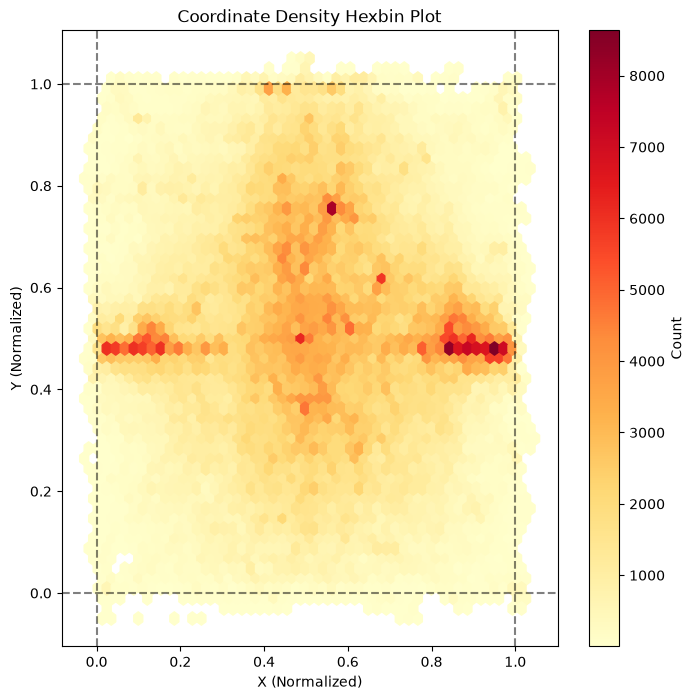

In [6]:
# 6. Coordinate Sanity Check
x_min, x_max = players_df['x'].min(), players_df['x'].max()
y_min, y_max = players_df['y'].min(), players_df['y'].max()

# Total non-null coordinate points
total_coords = players_df['x'].dropna().count()

# Out of bounds coordinates (outside [0.0, 1.0])
out_of_bounds_x = ((players_df['x'] < 0.0) | (players_df['x'] > 1.0)).sum()
out_of_bounds_y = ((players_df['y'] < 0.0) | (players_df['y'] > 1.0)).sum()
out_of_bounds_total = ((players_df['x'] < 0.0) | (players_df['x'] > 1.0) | (players_df['y'] < 0.0) | (players_df['y'] > 1.0)).sum()

pct_out_bounds = (out_of_bounds_total / total_coords) * 100

coord_sanity_df = pd.DataFrame({
    'Metric': ['X Min', 'X Max', 'Y Min', 'Y Max', 'Out-of-Bounds X count', 'Out-of-Bounds Y count', 'Total Out-of-Bounds coordinates', 'Percentage Out-of-Bounds (%)'],
    'Value': [f"{x_min:.5f}", f"{x_max:.5f}", f"{y_min:.5f}", f"{y_max:.5f}", out_of_bounds_x, out_of_bounds_y, out_of_bounds_total, f"{pct_out_bounds:.4f}%"]
})

print("### Coordinate Sanity Table")
print(coord_sanity_df.to_string(index=False))

# Plot coordinate distribution to visually check sanity
plt.figure(figsize=(8, 8))
plt.hexbin(players_df['x'].dropna(), players_df['y'].dropna(), gridsize=50, cmap='YlOrRd', mincnt=1)
plt.axvline(0.0, color='black', linestyle='--', alpha=0.5)
plt.axvline(1.0, color='black', linestyle='--', alpha=0.5)
plt.axhline(0.0, color='black', linestyle='--', alpha=0.5)
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)
plt.title('Coordinate Density Hexbin Plot')
plt.xlabel('X (Normalized)')
plt.ylabel('Y (Normalized)')
plt.colorbar(label='Count')
plt.savefig('../../results/figures/coordinate_density_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Motion Statistics and Extreme Jumps

We calculate consecutive frame displacements and speeds (in normalized units/sec) to identify unphysical track jumps (noise). We define an extreme jump as speed > 0.25 normalized units per second (approx 25 m/s).


### Motion Statistics and Extreme Jumps Table
                             Metric   Value
  Max Displacement per Frame (norm) 1.19647
 Mean Displacement per Frame (norm) 0.00081
                 Max Speed (norm/s) 29.9118
                Mean Speed (norm/s)  0.0204
Extreme Jumps Count (> 0.25 norm/s)     194
       Extreme Jumps Percentage (%) 0.0061%


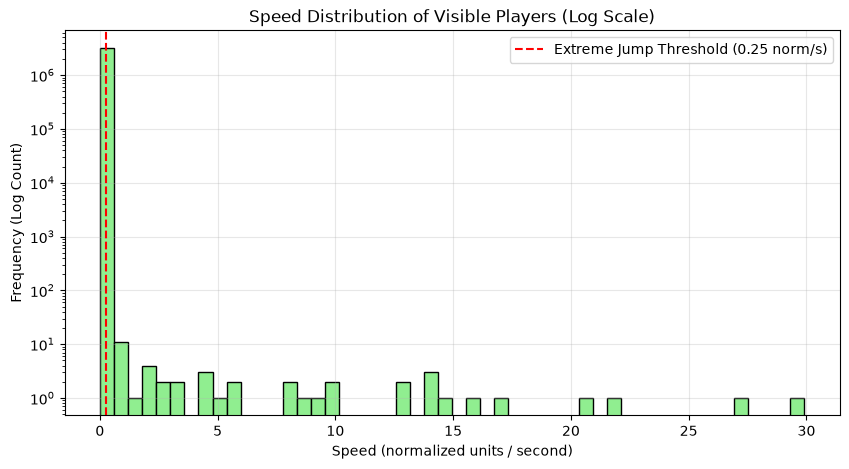

In [7]:
# 7. Motion Statistics and Extreme Jumps Analysis
displacements = []
speeds = []

for (team, pid), group in players_df.groupby(['team', 'player_id']):
    sorted_group = group.sort_values('frame').copy()
    sorted_group['prev_x'] = sorted_group['x'].shift(1)
    sorted_group['prev_y'] = sorted_group['y'].shift(1)
    sorted_group['prev_frame'] = sorted_group['frame'].shift(1)
    sorted_group['prev_visible'] = sorted_group['visible'].shift(1)
    
    consec = sorted_group[
        sorted_group['visible'] & 
        sorted_group['prev_visible'] & 
        ((sorted_group['frame'] - sorted_group['prev_frame']) == 1)
    ].copy()
    
    if consec.empty:
        continue
        
    dx = consec['x'] - consec['prev_x']
    dy = consec['y'] - consec['prev_y']
    consec['disp'] = np.sqrt(dx**2 + dy**2)
    consec['speed'] = consec['disp'] * fps
    
    displacements.extend(consec['disp'].tolist())
    speeds.extend(consec['speed'].tolist())

speeds_series = pd.Series(speeds)
displacements_series = pd.Series(displacements)

# Define extreme jump threshold:
# Speed of 0.25 normalized units per second (approx 25 m/s) is physically impossible
extreme_jump_threshold = 0.25
extreme_jumps_count = (speeds_series > extreme_jump_threshold).sum()
extreme_jumps_pct = (extreme_jumps_count / len(speeds_series)) * 100

motion_stats_df = pd.DataFrame({
    'Metric': [
        'Max Displacement per Frame (norm)', 'Mean Displacement per Frame (norm)',
        'Max Speed (norm/s)', 'Mean Speed (norm/s)',
        'Extreme Jumps Count (> 0.25 norm/s)', 'Extreme Jumps Percentage (%)'
    ],
    'Value': [
        f"{displacements_series.max():.5f}", f"{displacements_series.mean():.5f}",
        f"{speeds_series.max():.4f}", f"{speeds_series.mean():.4f}",
        extreme_jumps_count, f"{extreme_jumps_pct:.4f}%"
    ]
})

print("### Motion Statistics and Extreme Jumps Table")
print(motion_stats_df.to_string(index=False))

# Plot speed distribution
plt.figure(figsize=(10, 5))
plt.hist(speeds_series, bins=50, color='lightgreen', edgecolor='black', log=True)
plt.axvline(extreme_jump_threshold, color='red', linestyle='--', label=f'Extreme Jump Threshold ({extreme_jump_threshold} norm/s)')
plt.title('Speed Distribution of Visible Players (Log Scale)')
plt.xlabel('Speed (normalized units / second)')
plt.ylabel('Frequency (Log Count)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../results/figures/speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Summary Table for Final Report

We present a compact summary table of the key findings suitable for reporting.


In [8]:
# 10. Compact Summary Table for Final Reporting
summary_table_df = pd.DataFrame({
    'Dimension': [
        'Dataset Size', 'Dataset Length', 'Temporal Resolution',
        'Roster Coverage', 'Player Visibility', 'Frame Completeness',
        'Spatial Boundaries', 'Spatial Out-of-Bounds', 'Motion Anomalies'
    ],
    'Metric/Description': [
        'Total frames loaded', 'Total duration of match', 'Frames per second (FPS)',
        'Unique players tracked', 'Mean player visibility percentage',
        'Percentage of frames with 22+ visible players',
        'Coordinate ranges (X / Y)', 'Percentage of out-of-bounds coords',
        'Extreme speed jumps (> 0.25 norm/s)'
    ],
    'Value': [
        f"{total_frames:,}", f"{duration:.2f} s", f"{fps:.1f} Hz",
        f"{unique_players} players ({home_players} Home, {away_players} Away)",
        f"{player_stats_df['Visibility %'].apply(lambda x: float(x.replace('%', ''))).mean():.2f}%",
        f"{p_22_or_more:.2f}%",
        f"X: [{x_min:.4f}, {x_max:.4f}] / Y: [{y_min:.4f}, {y_max:.4f}]",
        f"{pct_out_bounds:.4f}%",
        f"{extreme_jumps_count} jumps ({extreme_jumps_pct:.4f}%)"
    ]
})

print("### Metrica Tracking Quality Summary Table")
print(summary_table_df.to_string(index=False))


### Metrica Tracking Quality Summary Table
            Dimension                            Metric/Description                                       Value
         Dataset Size                           Total frames loaded                                     145,006
       Dataset Length                       Total duration of match                                   5800.20 s
  Temporal Resolution                       Frames per second (FPS)                                     25.0 Hz
      Roster Coverage                        Unique players tracked               28 players (14 Home, 14 Away)
    Player Visibility             Mean player visibility percentage                                      78.57%
   Frame Completeness Percentage of frames with 22+ visible players                                     100.00%
   Spatial Boundaries                     Coordinate ranges (X / Y) X: [-0.0297, 1.0472] / Y: [-0.0500, 1.0500]
Spatial Out-of-Bounds            Percentage of out-of-bounds 